# Malatya Fault M7.2 Scenario

## 1. Setup

In [1]:
import os, json, shutil
from pathlib import Path
import xml.etree.ElementTree as ET
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import base64
from IPython.display import HTML

EVENT = 'malatya_fault_se'
os.environ['EVENT'] = EVENT

EVENT_DIR = Path.home() / 'shakemap_profiles/default/data' / EVENT / 'current'
PRODUCTS  = EVENT_DIR / 'products'
GF_OUT    = Path.home() / 'gf_output' / EVENT
TR_DATA   = Path.home() / 'turkey_inputs'

## 2. Malatya Fault Rupture

The Malatya Fault is a left-lateral strike-slip fault system in eastern Turkey, 
approximately 50 km northwest of Malatya city.

We use a M7.2 scenario rupture of the full fault system as a planning scenario 
for this region.

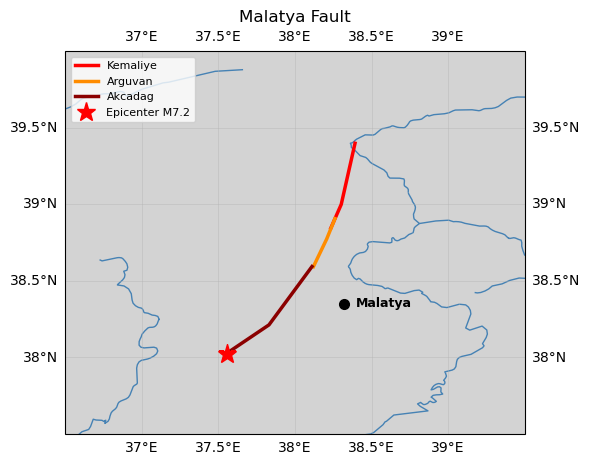

In [2]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Segment traces from AFAD shapefile
segments = {
    'Kemaliye': {'lons': [38.392, 38.302, 38.234], 'lats': [39.399, 39.000, 38.845], 'color': 'red'},
    'Arguvan':  {'lons': [38.261, 38.207, 38.120], 'lats': [38.907, 38.774, 38.593], 'color': 'darkorange'},
    'Akcadag':  {'lons': [38.111, 37.830, 37.545], 'lats': [38.594, 38.213, 38.021], 'color': 'darkred'},
}

fig, ax = plt.subplots(figsize=(6, 8), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([36.5, 39.5, 37.5, 40.0], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, facecolor='lightgray')
ax.add_feature(cfeature.RIVERS, edgecolor='steelblue')
ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)

for label, seg in segments.items():
    ax.plot(seg['lons'], seg['lats'], '-', color=seg['color'],
            linewidth=2.5, transform=ccrs.PlateCarree(), label=label)

ax.plot(37.555, 38.024, '*', color='red', markersize=14,
        transform=ccrs.PlateCarree(), label='Epicenter M7.2', zorder=10)
# Malatya city
ax.plot(38.32, 38.35, 'o', color='black', markersize=7,
        transform=ccrs.PlateCarree(), zorder=11)
ax.text(38.40, 38.35, 'Malatya', fontsize=9, fontweight='bold',
        transform=ccrs.PlateCarree(), va='center', zorder=11)

ax.legend(fontsize=8, loc='upper left')
ax.set_title('Malatya Fault')
plt.tight_layout()
plt.show()

### From fault trace to rupture.json

A ShakeMap `rupture.json` defines the fault plane as a closed polygon:

- **Top edge** — the surface trace coordinates at depth = 0 km
- **Bottom edge** — the same lon/lat coordinates at depth = 15 km (seismogenic depth)
- For a vertical fault (dip = 90°) the top and bottom edges are directly above each other

Each segment becomes one polygon in a `MultiPolygon` geometry.
For this scenario, the rupture was built from the AFAD shapefile trace.

In [3]:
print("Key vertices from AFAD 2026 shapefile")
print()
print(f"{'Segment':<20} {'Lon':>10} {'Lat':>10}  Point")
print("-" * 58)
vertices = [
    ("Kemaliye", 38.392, 39.399, "N tip"),
    ("", 38.302, 39.000, "mid"),
    ("", 38.234, 38.845, "S tip"),
    ("Arguvan",  38.261, 38.907, "N tip"),
    ("", 38.207, 38.774, "mid"),
    ("", 38.120, 38.593, "S tip"),
    ("Akcadag",  38.111, 38.594, "N tip"),
    ("", 37.830, 38.213, "mid"),
    ("", 37.545, 38.021, "S tip"),
]
for seg, lon, lat, label in vertices:
    print(f"{seg:<20} {lon:>10.3f} {lat:>10.3f}  {label}")
print()
print("Each segment repeated at depth=15 km forms the bottom edge of the fault plane.")

Key vertices from AFAD 2026 shapefile

Segment                     Lon        Lat  Point
----------------------------------------------------------
Kemaliye                 38.392     39.399  N tip
                         38.302     39.000  mid
                         38.234     38.845  S tip
Arguvan                  38.261     38.907  N tip
                         38.207     38.774  mid
                         38.120     38.593  S tip
Akcadag                  38.111     38.594  N tip
                         37.830     38.213  mid
                         37.545     38.021  S tip

Each segment repeated at depth=15 km forms the bottom edge of the fault plane.


Let's take a look at what this looks like in the `rupture.json` format. 

In [6]:
rupture_path = EVENT_DIR / "rupture.json"
with rupture_path.open(encoding="utf-8") as f:
    rupture = json.load(f)
print(type(rupture))
print(rupture.keys())

<class 'dict'>
dict_keys(['type', 'metadata', 'features'])


In [7]:
print(rupture["metadata"].keys())
print(rupture["metadata"]["reference"])

dict_keys(['reference', 'magnitude', 'strike', 'dip', 'rake', 'depth'])
Malatya Fault (Kemaliye Segment) — AFAD 2026 (segmented geometry)


In [8]:
print(type(rupture["features"]))
print(rupture["features"][0].keys())
print(rupture["features"][0]["geometry"])

<class 'list'>
dict_keys(['type', 'properties', 'geometry'])
{'type': 'MultiPolygon', 'coordinates': [[[[38.39174875700013, 39.39870630800016, 0.0], [38.405430658, 39.38159798300012, 0.0], [38.41171595700001, 39.368640497, 0.0], [38.40486310900002, 39.360283830000014, 0.0], [38.409165175, 39.350080701000024, 0.0], [38.41369566800017, 39.334680829000035, 0.0], [38.41956773200019, 39.314815354000075, 0.0], [38.41963911600004, 39.28991429399997, 0.0], [38.41542984900019, 39.263733878000096, 0.0], [38.417704614, 39.253786938000076, 0.0], [38.41473248900007, 39.23647980900006, 0.0], [38.41068740500003, 39.2140795630001, 0.0], [38.408660104000035, 39.197932541000114, 0.0], [38.40477682400012, 39.18245652700017, 0.0], [38.40133433900013, 39.17117907100004, 0.0], [38.395238160000076, 39.15109166100012, 0.0], [38.38158824300018, 39.12302309300014, 0.0], [38.36873730900004, 39.098919788000046, 0.0], [38.35662228400014, 39.072461371000145, 0.0], [38.32542755000014, 39.03543695800016, 0.0], [38.30

## 2. Run ShakeMap

**Magnitude M7.2** is a rough estimate from the fault length using the
Wells & Coppersmith (1994) scaling relationship for strike-slip faults.

The same ShakeMap pipeline as the morning demo:
- **`assemble`** — collect inputs (event origin + fault geometry + site conditions)
- **`model`** — compute ground motion using GMMs + Vs30 (expect ~2 min for this extent)
- **`contour`**, **`mapping`**, **`gridxml`** — outputs for visualization and ground failure

In [10]:
# The input directory already exists
print(EVENT_DIR)
(EVENT_DIR / 'event.xml').exists()

/home/vscode/shakemap_profiles/default/data/malatya_fault_se/current


True

In [11]:
%%bash
shake $EVENT assemble -c 'demo' model contour mapping gridxml

INFO -- 2026-08-31 12:46:26 -- shake.main -- Running command assemble
INFO -- 2026-08-31 12:46:26 -- shake.main -- Finished running command assemble: Elapsed 0.24 secs
INFO -- 2026-08-31 12:46:26 -- shake.main -- Running command model
INFO -- 2026-08-31 12:46:26 -- model._threading_context -- BLAS thread limit: native/unrestricted (not set by ShakeMap)
INFO -- 2026-08-31 12:46:26 -- model._threading_context -- OpenMP thread limit: native/unrestricted (not set by ShakeMap)
INFO -- 2026-08-31 12:46:27 -- output_grid._adjust_resolution -- Resolution units specified in km, converting to degrees.
INFO -- 2026-08-31 12:46:27 -- output_grid._adjust_resolution -- Updated dx: 0.011518 (degrees)
INFO -- 2026-08-31 12:46:27 -- output_grid._adjust_resolution -- Updated dy: 0.0089932 (degrees)
INFO -- 2026-08-31 12:47:00 -- shake.main -- Finished running command model: Elapsed 33.74 secs
INFO -- 2026-08-31 12:47:00 -- shake.main -- Running command contour
INFO -- 2026-08-31 12:47:06 -- shake.main -

Now we will copy the result somewhere else so that we can compare it to another result later. 

In [12]:
%%bash
cp ~/shakemap_profiles/default/data/$EVENT/current/products/grid.xml ~/malatya_global_vs30_grid.xml

## 3. ShakeMap maps

Because we provided a finite fault geometry, shaking is elongated along the
N15°E fault strike rather than the circular pattern of a point source.
Compare the shaking footprint to the M7.6 San Andreas map from this morning —
note how local geology (Vs30) modifies the pattern.

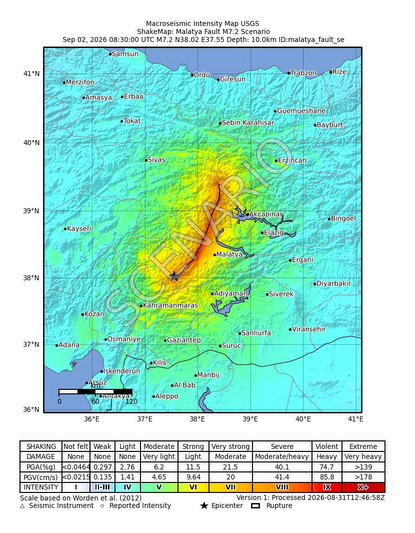

In [14]:
img = mpimg.imread(str(PRODUCTS / 'intensity.jpg'))
h, w = img.shape[:2]
fig, ax = plt.subplots(figsize=(w/300, h/300), dpi=150)
ax.imshow(img, interpolation='lanczos')
ax.axis('off')
plt.tight_layout(pad=0)
plt.show()

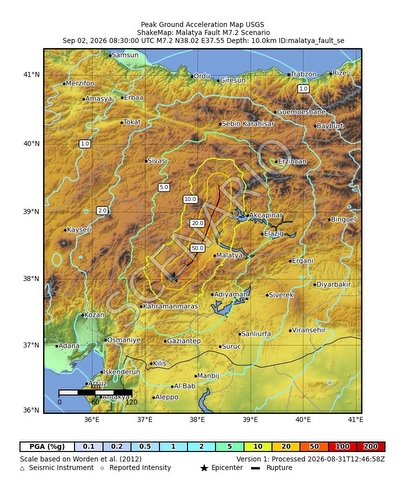

In [15]:
img = mpimg.imread(str(PRODUCTS / 'pga.jpg'))
h, w = img.shape[:2]
fig, ax = plt.subplots(figsize=(w/300, h/300), dpi=150)
ax.imshow(img, interpolation='lanczos')
ax.axis('off')
plt.tight_layout(pad=0)
plt.show()

**Discussion:**
- Which cities appear to experience the highest shaking?
- How does the shaking pattern compare to the San Andreas scenario from this morning?
- Are there modeling choices you might want to investigate? 
- Other questions? 

## 4. Ground Failure

Ground failure models estimate where earthquake shaking is likely to trigger
landslides and liquefaction. We compare two families of models:

**Global models** — We have included the input layers for Turkiye for the two primary operational USGS models, Jessee et al. (2018) for landslides and Zhu et al. (2017) for liquefaction. These are trained on inventories worldwide and are what USGS runs operationally. The older Zhu et al. (2015) global liquefaction model can also be run.

**Regional models** — trained either specifically on Turkish data and data from similar settings or global models run with local inputs. These should capture local conditions better, but alert thresholds have not been calibrated for them, so they should be run without `-w` if they are run without the jessee and zhu_2017 models.

We have included the input layers so you can run any of the following models:

Landslide models:
* jessee_2018_slim.ini - Primary global landslide model with pre-combined static inputs
* allstadt_2026_mediterranean_prelim.ini - Preliminary regional landslide model trained on 6 inventories from Mediterranean-like climates
* allstadt_2026_turkiye2023_prelim.ini - Preliminary regional landslide model trained on just the Turkiye 2023 landslide inventory

Liquefaction models:
* zhu_2017_general_slim.ini - Primary global liquefaction model
* zhu_2015.ini - Older global liquefaction model.
* asadi_2024_europe.ini - Regional liquefaction model that was created by recalibrating the Zhu et al 2017 model using European liquefaction datasets, not converted to areal coverage (relative hazard)
* asadi_2024_turkiye.ini - Regional liquefaction model that was created by recalibrating the Zhu et al 2017 model using Turkish liquefaction datasets, not converted to areal coverage (relative hazard)
* asadi_2024_turkiye2023.ini - Regional liquefaction model that was created by recalibrating the Zhu et al 2017 model using just the Turkiye 2023 liquefaction inventory, not converted to areal coverage (relative hazard)
* zhu_2017_coastal.ini - Global liquefaction model only valid in coastal areas (not appropriate for Malatya)

We have also included some regional input layers you can use to replace the global susceptibility proxies in the liquefaction models for better performance.

We show examples of how to run everything below and you can decide what to run and what to look at by modifying the notebook. There are embedded notebooks and image plots, but you may prefer to download and and view/compare files in QGIS or Google Earth to have more freedom.

### Create list of model configuration files to run

First let's make a text file listing all the models you want to run. The jessee and zhu_2017_general models must be run to generate the alert levels (for the `-w` flag), but you can uncomment any of the other models you also want to run in the next code section. Just note that the more models you run, the longer it will take. Note, we can use relative paths to the model config files because we're using the default model files and the codes know where to find them.

In [9]:
# Write the config list of the two primary models
CONFIG1="/workspaces/shakemap-gf-workshop/data/gf_configs_primary.txt"
models = [
    'jessee_2018_slim.ini',
    'zhu_2017_general_slim.ini'
]
# Open the file in write mode and save the lines
with open(CONFIG1, "w") as file:
    for line in models:
        file.write(line+'\n')

# Write a config list of the alternate models

CONFIG2="/workspaces/shakemap-gf-workshop/data/gf_configs_turkey.txt"
# comment out any models you don't want to run right now
models = [
    'allstadt_2026_mediterranean_prelim.ini',
    'allstadt_2026_turkiye2023_prelim.ini',
    # 'zhu_2015.ini',
    # 'asadi_2024_europe.ini',
    'asadi_2024_turkiye.ini',
    # 'asadi_2024_turkiye2023.ini',
]

# Open the file in write mode and save the lines
with open(CONFIG2, "w") as file:
    for line in models:
        file.write(line+'\n')

We also need to modify a few of the default model configuration files because we have different file extensions for some of the inputs:

In [3]:
import os

# Make a copy of the Zhu et al 2017 model configuration file and modify the input layers
files_to_fix = ["zhu_2017_general.ini", 'zhu_2015.ini', 'asadi_2024_europe.ini', 'asadi_2024_turkiye.ini', 'asadi_2024_turkiye2023.ini',]
for filen in files_to_fix:
    source_file = f"/home/vscode/groundfailure/defaultconfigfiles/models/{filen}"

    # Read in the copied over model configuration file
    with open(source_file, "r", encoding="utf-8") as file:
        content = file.read()
    modified_content = content.replace('global_precip_fil_mm.grd', 'global_precip_fil_mm.tif')
    modified_content = modified_content.replace("global_vs30_mps.grd", "global_vs30_mps.tif")
    modified_content = modified_content.replace("global_wtd_fil_na_m.grd", "global_wtd_fil_na_m.tif")

    # Overwrite the file with the modified content
    with open(source_file, "w", encoding="utf-8") as file:
        file.write(modified_content)

### Run the models

So we don't have to change the Kernal for the notebook to switch to the `gf` conda environment, we'll run `gfailbin` using the full path to the function in the gf environment. Alternatively, you can run these commands from the terminal after switching to the `gf` environment by typing `conda activate gf`.

In [10]:
%%bash
# Make the output directory in case it wasn't already made in previous notebook
export OUTDIR=/home/vscode/gf_output
mkdir $OUTDIR -p

export EVENT=malatya_fault_se
/opt/conda/envs/gf/bin/gfailbin \
  /workspaces/shakemap-gf-workshop/data/gf_configs_primary.txt \
  ~/shakemap_profiles/default/data/$EVENT/current/products/grid.xml \
  --gis --kmz -w \
  -d /workspaces/shakemap-gf-workshop/data/turkey_inputs \
  -pf /workspaces/shakemap-gf-workshop/data/turkey_inputs/ghsl_pop_tur_2025.tif \
  -o $OUTDIR


Running the following models:
	jessee_2018_slim
	zhu_2017_general_slim
Applying bounds of lonmin 35.07, lonmax 41.12, latmin 35.94, latmax 41.38
Unable to determine source type, unknown if finite fault or point source

Now running jessee_2018_slim:



Now running zhu_2017_general_slim:
No uncertainty provided, filling with zeros
No uncertainty provided, filling with zeros

Files created:

/home/vscode/gf_output/malatya_fault_se/shakefile.txt
malatya_fault_se_jessee_2018_slim.hdf5
/home/vscode/gf_output/malatya_fault_se/malatya_fault_se_jessee_2018_slim_model.tif
/home/vscode/gf_output/malatya_fault_se/malatya_fault_se_jessee_2018_slim_model.kmz
malatya_fault_se_zhu_2017_general_slim.hdf5
/home/vscode/gf_output/malatya_fault_se/malatya_fault_se_zhu_2017_general_slim_model.tif
/home/vscode/gf_output/malatya_fault_se/malatya_fault_se_zhu_2017_general_slim_model.kmz
['/home/vscode/gf_output/malatya_fault_se/jessee_2018_extent.json', '/home/vscode/gf_output/malatya_fault_se/zhu_2017_general_extent.json', '/home/vscode/gf_output/malatya_fault_se/zhu_2017_general.png']
['/home/vscode/gf_output/malatya_fault_se/info.json']


And now we'll run the alternative models (without the `-w` flag)

In [11]:
%%bash
# Make the output directory in case it wasn't already made in previous notebook
export OUTDIR=/home/vscode/gf_output
mkdir $OUTDIR -p

export EVENT=malatya_fault_se
/opt/conda/envs/gf/bin/gfailbin \
  /workspaces/shakemap-gf-workshop/data/gf_configs_turkey.txt \
  ~/shakemap_profiles/default/data/$EVENT/current/products/grid.xml \
  --gis --kmz \
  -d /workspaces/shakemap-gf-workshop/data/turkey_inputs \
  -o $OUTDIR


Running the following models:
	allstadt_2026_mediterranean_prelim
	allstadt_2026_turkiye2023_prelim
	asadi_2024_turkiye
Applying bounds of lonmin 35.07, lonmax 41.12, latmin 35.94, latmax 41.38
Unable to determine source type, unknown if finite fault or point source

Now running allstadt_2026_mediterranean_prelim:

The following input layers do not cover the area of interest:
	/workspaces/shakemap-gf-workshop/data/turkey_inputs/global_Verdin_slopes_resampled_degx100/slope_max.bil
Running model for new bounds that are fully covered by input layer: 35.116699999999994, 41.0657, 35.988299999999995, 40.954126265

Now running allstadt_2026_turkiye2023_prelim:

The following input layers do not cover the area of interest:
	/workspaces/shakemap-gf-workshop/data/turkey_inputs/global_Verdin_slopes_resampled_degx100/slope_max.bil
Running model for new bounds that are fully covered by input layer: 35.116699999999994, 41.0657, 35.988299999999995, 40.954126265

Now running asadi_2024_turkiye:

File

## 5. Interactive ground failure maps

This section embeds interactive side by side comparison maps of two ground failure models using a custom function. Change the "model" files in any of the calls below to one of the model names from the list you ran above to view a different comparison.

### Standard (primary) global ground failure models
Landslide (left) and liquefaction (right) with shaking contours overlaid.
Download `malatya_gf.html` (Explorer → right-click → Download) to open in a browser.

In [14]:
%%bash
export EVENT=malatya_fault_se
M=$HOME/groundfailure/defaultconfigfiles/models
G=$HOME/gf_output/$EVENT
/opt/conda/envs/gf/bin/python ~/plot_gf_interactive.py \
  --model "Jessee 2018:$G/${EVENT}_jessee_2018_slim_model.tif:$M/jessee_2018_slim.ini" \
  --model "Zhu 2017:$G/${EVENT}_zhu_2017_general_slim_model.tif:$M/zhu_2017_general_slim.ini" \
  --shakefile ~/shakemap_profiles/default/data/$EVENT/current/products/grid.xml \
  --contours  ~/shakemap_profiles/default/data/$EVENT/current/products/cont_mmi.json \
  --infojson  $G/info.json \
  --outfile ~/malatya_gf_global.html

Reading /home/vscode/gf_output/malatya_fault_se/malatya_fault_se_jessee_2018_slim_model.tif...
Reading /home/vscode/gf_output/malatya_fault_se/malatya_fault_se_zhu_2017_general_slim_model.tif...
Saved: /home/vscode/malatya_gf_global.html
[Jessee 2018] max P: 0.2447, area>0.002: 5.8%
[Zhu 2017] max P: 0.2810, area>0.005: 5.3%


In [21]:
html_path = Path.home() / 'malatya_gf_global.html'
b64 = base64.b64encode(html_path.read_bytes()).decode()
HTML(f'<iframe src="data:text/html;base64,{b64}" width="100%" height="600px"></iframe>')

/opt/conda/envs/shakemap/lib/python3.12/site-packages/IPython/core/display.py:448: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


### Compare global to regional landslide models

This compares the primary global model (jessee) to the new "Mediterranean model"
Also try swapping out the REGMODEL line for the one commented below it to compare to the Turkiye-specific model instead.

In [ ]:
%%bash
export EVENT=malatya_fault_se
export REGMODEL=allstadt_2026_mediterranean_prelim_model
# export REGMODEL=allstadt_2026_turkiye2023_prelim_model
M=$HOME/groundfailure/defaultconfigfiles/models
G=$HOME/gf_output/$EVENT
REGCONFIG=${REGMODEL%_model}
/opt/conda/envs/gf/bin/python ~/plot_gf_interactive.py \
  --model "Jessee 2018 (global):$G/${EVENT}_jessee_2018_slim_model.tif:$M/jessee_2018_slim.ini" \
  --model "Allstadt 2026 (regional):$G/${EVENT}_${REGMODEL}.tif:$M/${REGCONFIG}.ini" \
  --shakefile ~/shakemap_profiles/default/data/$EVENT/current/products/grid.xml \
  --contours  ~/shakemap_profiles/default/data/$EVENT/current/products/cont_mmi.json \
  --infojson  $G/info.json \
  --outfile ~/malatya_gf_landslide.html

Reading /home/vscode/gf_output/malatya_fault_se/malatya_fault_se_jessee_2018_slim_model.tif...
Reading /home/vscode/gf_output/malatya_fault_se/malatya_fault_se_allstadt_2026_mediterranean_prelim_model.tif...


Saved: /home/vscode/malatya_gf_landslide.html
[Jessee 2018 (global)] max P: 0.2447, area>0.002: 5.8%
[Allstadt 2026 (regional)] max P: 0.6882, area>0.002: 1.7%


In [22]:
html_path = Path.home() / 'malatya_gf_landslide.html'
b64 = base64.b64encode(html_path.read_bytes()).decode()
HTML(f'<iframe src="data:text/html;base64,{b64}" width="100%" height="600px"></iframe>')

/opt/conda/envs/shakemap/lib/python3.12/site-packages/IPython/core/display.py:448: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


**Discussion:**
- Where are the highest landslide probabilities? Does that match your expectation
  based on the terrain?
- Where is the estimated liquefaction hazard concentrated? What does that suggest about the
  near-surface geology in those areas?
- How might ground failure affect emergency response — which roads or
  infrastructure might be disrupted?

---
## 6. Replace global inputs with higher quality regional inputs

### Higher resolution Vs30 for ShakeMap

Vs30 is the seismic shear wave velocity at 30 m depth. It is used by ShakeMap to model how the shallow subsurface modifies the ground motions.

The AFAD regional Vs30 map for Turkey captures site conditions at 300 m.

This is finer than the global Vs30 map (~1 km).
This matters in urban areas where basin sediments amplify shaking.

In [19]:
AFAD_VS30  = Path('/workspaces/shakemap-gf-workshop/data/vs30/afad_turkey_vs30_filled.tif')
model_conf = EVENT_DIR / 'model.conf'
orig_conf  = model_conf.read_text() if model_conf.exists() else ''

if AFAD_VS30.exists():
    model_conf.write_text(orig_conf + f"""
[data]
    vs30file = {AFAD_VS30}
""")
    print('Switched to AFAD regional Vs30')
else:
    print('AFAD Vs30 not yet available in this image — skip this option')

Switched to AFAD regional Vs30


In [20]:
%%bash
shake $EVENT assemble -c 'AFAD Vs30' model contour mapping

INFO -- 2026-08-26 17:56:21 -- shake.main -- Running command assemble
INFO -- 2026-08-26 17:56:21 -- shake.main -- Finished running command assemble: Elapsed 0.09 secs
INFO -- 2026-08-26 17:56:21 -- shake.main -- Running command model
INFO -- 2026-08-26 17:56:21 -- model._threading_context -- BLAS thread limit: native/unrestricted (not set by ShakeMap)
INFO -- 2026-08-26 17:56:21 -- model._threading_context -- OpenMP thread limit: native/unrestricted (not set by ShakeMap)
INFO -- 2026-08-26 17:56:21 -- output_grid._adjust_resolution -- Resolution units specified in km, converting to degrees.
INFO -- 2026-08-26 17:56:21 -- output_grid._adjust_resolution -- Updated dx: 0.011518 (degrees)
INFO -- 2026-08-26 17:56:21 -- output_grid._adjust_resolution -- Updated dy: 0.0089932 (degrees)
INFO -- 2026-08-26 17:56:51 -- shake.main -- Finished running command model: Elapsed 29.83 secs
INFO -- 2026-08-26 17:56:51 -- shake.main -- Running command contour
INFO -- 2026-08-26 17:56:56 -- shake.main -

In [ ]:
%%bash
shake $EVENT gridxml
sm_compare \
  ~/shakemap_profiles/default/data/malatya_fault_se/current/products/grid.xml \
  ~/malatya_global_vs30_grid.xml \
  -i pga \
  -o ~/malatya_vs30_compare.png

INFO -- 2026-08-26 17:58:31 -- shake.main -- Running command gridxml
INFO -- 2026-08-26 17:58:34 -- shake.main -- Finished running command gridxml: Elapsed 2.88 secs
INFO -- 2026-08-26 17:58:34 -- shake.main -- shake finished with event malatya_fault_se
/opt/conda/envs/shakemap/lib/python3.12/site-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/10m_physical/ne_10m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


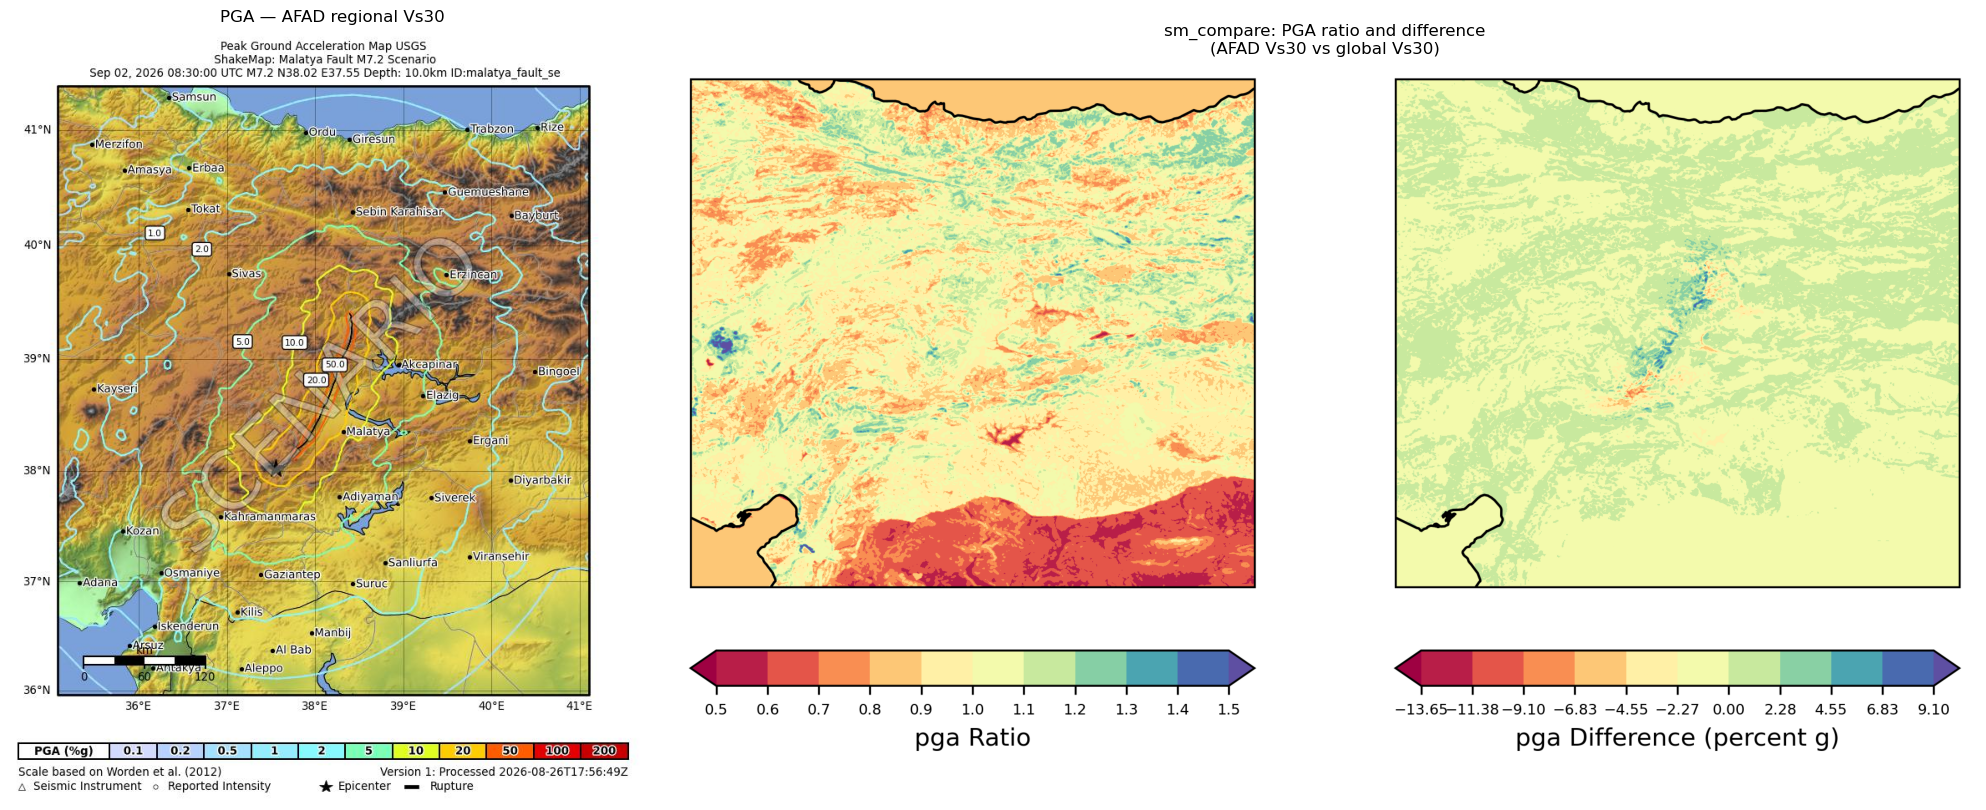

In [22]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

pga_map_path = PRODUCTS / 'pga.jpg'
compare_path = Path.home() / 'malatya_vs30_compare.png'

pga_img = mpimg.imread(str(pga_map_path))
compare_img = mpimg.imread(str(compare_path))

fig, axes = plt.subplots(1, 2, figsize=(20, 8),
                          gridspec_kw={'width_ratios': [1, 2]})

axes[0].imshow(pga_img)
axes[0].axis('off')
axes[0].set_title('PGA — AFAD regional Vs30', fontsize=12)

axes[1].imshow(compare_img)
axes[1].axis('off')
axes[1].set_title('sm_compare: PGA ratio and difference\n(AFAD Vs30 vs global Vs30)', fontsize=12)

plt.tight_layout()
plt.savefig(Path.home() / 'malatya_vs30_full_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Regional Vs30 and water table depth for liquefaction model

The liquefaction model inputs such as distance from water bodies, water table depth, and Vs30 can be swapped out for higher quality regional layers to try to improve performance. We already introduced the regional Vs30 model above. You can also experiment with substituting in a different water table depth layer, replacing the Fan et al. (2013) water table depth (resolution ) with an alternate global model, [GLOBGM](https://github.com/UU-Hydro/GLOBGM/tree/main) of the same 30 arc-sec resolution. How to do both is shown below, but you may want to vary just one or the other at a time so you can see the effects.

To do this, we first need to make a new copy of the model default configuration file. We will use the full model config file instead of the "slim" one because weneed to change only some of the names of the input files.

In [23]:
import os
import shutil

# Make a copy of the Zhu et al 2017 model configuration file and modify the input layers

source_file = "/home/vscode/groundfailure/defaultconfigfiles/models/zhu_2017_general.ini"
modified_modelconfig = "/workspaces/shakemap-gf-workshop/data/zhu_2017_modified_inputs.ini"

shutil.copy(source_file, modified_modelconfig) # note, this will overwrite a file if it's already there

# We'll also make a new folder for the outputs specific to regional models so it won't overwrite the standard model outputs
reg_outpath = "/home/vscode/gf_output/regional"
if not os.path.exists(reg_outpath):
    os.mkdir(reg_outpath)

# Read in the copied over model configuration file
with open(modified_modelconfig, "r", encoding="utf-8") as file:
    content = file.read()

# Replace the water table depth input file, comment this line out if you only want to change vs30
modified_content = content.replace('global_wtd_fil_na_m.grd', 'Mo_TUR_wtd-20151231.tif')
modified_content = content.replace('global_wtd_fil_na_m.tif', 'Mo_TUR_wtd-20151231.tif')


# Replace the Vs30 input file with the regional AFAD one, comment this line out if you only want to change water table depth
modified_content = content.replace("global_vs30_mps.grd", "afad_turkey_vs30_filled.tif")
modified_content = content.replace("global_vs30_mps.tif", "afad_turkey_vs30_filled.tif")

# Overwrite the file with the modified content
with open(modified_modelconfig, "w", encoding="utf-8") as file:
    file.write(modified_content)


# We also have to make a symbolic link to the vs30 file so it looks like it's in the turkey_inputs file, where all the input files need to be located
target = "/workspaces/shakemap-gf-workshop/data/vs30/afad_turkey_vs30_filled.tif"
link = "/workspaces/shakemap-gf-workshop/data/turkey_inputs/afad_turkey_vs30_filled.tif"

# Create the symlink
os.symlink(target, link)


Now we can run the regional modified model

In [24]:
%%bash
# Make the output directory in case it wasn't already made in previous notebook
export OUTDIR=/home/vscode/gf_output/regional
export REGCONFIG=/workspaces/shakemap-gf-workshop/data/zhu_2017_modified_inputs.ini

export EVENT=malatya_fault_se
/opt/conda/envs/gf/bin/gfailbin \
  $REGCONFIG \
  ~/shakemap_profiles/default/data/$EVENT/current/products/grid.xml \
  --gis --kmz \
  -d /workspaces/shakemap-gf-workshop/data/turkey_inputs \
  -o $OUTDIR


Running the following models:
	zhu_2017_general
Applying bounds of lonmin 35.07, lonmax 41.12, latmin 35.94, latmax 41.38
Unable to determine source type, unknown if finite fault or point source

Now running zhu_2017_general:

Files created:

/home/vscode/gf_output/regional/malatya_fault_se/shakefile.txt
/home/vscode/gf_output/regional/malatya_fault_se/malatya_fault_se_zhu_2017_general_model.tif
/home/vscode/gf_output/regional/malatya_fault_se/malatya_fault_se_zhu_2017_general_model.kmz


And now view the original version of the model (left) against the version with the updated input layers

In [3]:
%%bash
export EVENT=malatya_fault_se
export REGCONFIG=/workspaces/shakemap-gf-workshop/data/zhu_2017_modified_inputs.ini
export REGOUTDIR=/home/vscode/gf_output/regional

M=$HOME/groundfailure/defaultconfigfiles/models
G=$HOME/gf_output/$EVENT
/opt/conda/envs/gf/bin/python ~/plot_gf_interactive.py \
  --model "Zhu 2017:$G/${EVENT}_zhu_2017_general_slim_model.tif:$M/zhu_2017_general_slim.ini" \
  --model "Zhu 2017 (Regional inputs):$REGOUTDIR/$EVENT/${EVENT}_zhu_2017_general_model.tif:$REGCONFIG" \
  --shakefile ~/shakemap_profiles/default/data/$EVENT/current/products/grid.xml \
  --contours  ~/shakemap_profiles/default/data/$EVENT/current/products/cont_mmi.json \
  --infojson  $G/info.json \
  --outfile ~/malatya_gf_liquefaction.html

Reading /home/vscode/gf_output/malatya_fault_se/malatya_fault_se_zhu_2017_general_slim_model.tif...
Reading /home/vscode/gf_output/regional/malatya_fault_se/malatya_fault_se_zhu_2017_general_model.tif...
Saved: /home/vscode/malatya_gf_liquefaction.html
[Zhu 2017] max P: 0.2810, area>0.005: 5.3%
[Zhu 2017 (Regional inputs)] max P: 0.1532, area>0.005: 2.9%


And now embed the html comparison figure

In [4]:
html_path = Path.home() / 'malatya_gf_liquefaction.html'
b64 = base64.b64encode(html_path.read_bytes()).decode()
HTML(f'<iframe src="data:text/html;base64,{b64}" width="100%" height="600px"></iframe>')

/opt/conda/envs/shakemap/lib/python3.12/site-packages/IPython/core/display.py:448: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")


## USGS Scenario Event Webpage
The USGS is able to push scenarios to our webpages so that they render like a regular event page. We have posted the Malatya scenario product online at this link: [https://earthquake.usgs.gov/scenarios/eventpage/adhocmalatya_fault_se/executive](https://earthquake.usgs.gov/scenarios/eventpage/adhocmalatya_fault_se/executive)

**Discussion:**
- Why might the regional model differ from the global one?

---
*End of scenario*